In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from scipy.sparse import csr_matrix

In [2]:
# 1. 读取突变数据
print("读取突变数据...")
df = pd.read_excel('C:/毕业论文/数据/all_mut_robust_scaled_numeric.xlsx')
print(f"数据形状: {df.shape}")
print(f"列名: {df.columns.tolist()}")

读取突变数据...
数据形状: (4267, 19)
列名: ['Gene', 'Disease', 'Site', 'Mutation', 'Co.evolution', 'Entropy', 'Consurf_Score', 'RASA', 'ddG', 'Betweenness', 'Closeness', 'Eigenvector', 'CC', 'Hydrophobicity', 'Effectiveness', 'Sensitivity', 'MSF', 'DFI', 'Stiffness']


In [4]:
# 2. 定义特征权重
weights = {
    'Co.evolution': 9/126,
    'Entropy': 11/126,
    'Consurf_Score': 11/126,
    'RASA': 10/126,
    'ddG': 7/126,
    'Betweenness': 2/126,
    'Closeness': 18/126,
    'Eigenvector': 1/126,
    'CC': 1/126,
    'Hydrophobicity': 3/126,
    'Effectiveness': 10/126,
    'Sensitivity': 9/126,
    'MSF': 10/126,
    'DFI': 13/126,
    'Stiffness': 11/126
}


In [5]:
# 3. 定义网络节点和转移矩阵
# 网络节点顺序
nodes = [
    'Cluster1',
    'SOS(SOS1)',
    'Ras(KRAS)',
    'BRAF',
    'RAF1',
    'Cluster2(MEK1/2)',
    'ERK',
    'Cluster3',
    'PI3K(PIK3CA)',
    'PTEN',
    'AKT',
    'Cluster4',
    'IRS1'
]

# 转移矩阵数据（行对应From，列对应To）
transition_matrix = np.array([
    [0, 1/2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # Cluster1
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],    # SOS(SOS1)
    [0, 0, 0, 1/3, 1/4, 0, 0, 0, 1/2, 0, 0, 0, 0],  # Ras(KRAS)
    [0, 0, 0, 0, 1/4, 1/3, 0, 0, 0, 0, 0, 0, 0],   # BRAF
    [0, 0, 0, 1/3, 0, 1/3, 0, 0, 0, 0, 0, 0, 0],   # RAF1
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],       # Cluster2(MEK1/2)
    [-1, -1/2, 0, -1/3, -1/4, -1/3, 0, 1, 0, 0, 0, 0, 0],  # ERK
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],       # Cluster3
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1/2, 0, 0],     # PI3K(PIK3CA)
    [0, 0, 0, 0, 0, 0, 0, 0, -1/2, 0, -1/2, 0, 0], # PTEN
    [0, 0, 0, 0, -1/4, 0, 0, 0, 0, 0, 0, 1, -1],   # AKT
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],       # Cluster4
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]        # IRS1
])

# 确保每列和为1（概率转移矩阵要求）
#for i in range(transition_matrix.shape[1]):
#    col_sum = np.sum(transition_matrix[:, i])
#    if col_sum > 0:
#        transition_matrix[:, i] /= col_sum


In [6]:
# 4. 构建NetworkX图
print("\n构建NetworkX图...")
G = nx.DiGraph()
G.add_nodes_from(nodes)

# 添加带权重的边
for i, from_node in enumerate(nodes):
    for j, to_node in enumerate(nodes):
        weight = transition_matrix[i, j]
        if weight != 0:
            G.add_edge(from_node, to_node, weight=weight)


构建NetworkX图...


In [9]:
# 5. 基因名到网络节点的映射
# 根据您提供的网络结构
gene_to_node = {
    'PTPN11': 'Cluster1',      # PTPN11映射到Cluster1
    'SOS1': 'SOS(SOS1)',
    'KRAS': 'Ras(KRAS)',       # KRAS映射到Ras(KRAS)
    'BRAF': 'BRAF',
    'RAF1': 'RAF1',
    'MEK1': 'Cluster2(MEK1/2)',  # MEK1属于cluster2
    'MEK2': 'Cluster2(MEK1/2)',  # MEK2属于cluster2
    'PIK3CA': 'PI3K(PIK3CA)',
    'PTEN': 'PTEN',
    'AKT': 'AKT',
    'ERK': 'ERK'
}

In [7]:
# 6. RWR算法实现
def rwr_with_restart(transition_matrix, p0, r=0.7, max_iter=1000, tol=1e-6):
    """
    执行带重启的随机游走
    
    参数:
    transition_matrix: 转移概率矩阵
    p0: 初始概率向量
    r: 重启概率
    max_iter: 最大迭代次数
    tol: 收敛容差
    
    返回:
    p: 稳态概率向量
    """
    n = len(p0)
    p_prev = p0.copy()
    
    for iteration in range(max_iter):
        # 计算随机游走部分: (1-r) * M^T * p_prev
        p_new = (1 - r) * transition_matrix.T @ p_prev
        
        # 添加重启部分: r * p0
        p_new += r * p0
        
        # 检查收敛
        diff = np.linalg.norm(p_new - p_prev, 1)
        
        if diff < tol:
            print(f"  收敛于第 {iteration+1} 次迭代, 差异: {diff:.10f}")
            return p_new
        
        p_prev = p_new
    
    print(f"  达到最大迭代次数 {max_iter}, 最终差异: {diff:.10f}")
    return p_prev

In [10]:
# 7. 为每个突变执行RWR
print("\n为每个突变执行RWR分析...")
results = []

for idx, row in df.iterrows():
    if idx % 500 == 0:
        print(f"  处理第 {idx} 个突变...")
    
    # 获取基因名
    gene = row['Gene']
    
    # 映射到网络节点
    if gene in gene_to_node:
        node_name = gene_to_node[gene]
    elif gene == 'PTPN11':  # 示例数据中有PTPN11，但不在网络中
        # 这里可以根据需要处理不在网络中的基因
        # 暂时跳过或使用默认节点
        results.append([None] * len(nodes))
        continue
    else:
        # 对于不在映射表中的基因，跳过或使用默认处理
        results.append([None] * len(nodes))
        continue
    
    # 计算初始值：特征加权和
    initial_value = 0
    for feature, weight in weights.items():
        initial_value += row[feature] * weight
    
    # 构建初始向量p0
    p0 = np.zeros(len(nodes))
    node_index = nodes.index(node_name)
    p0[node_index] = initial_value
    
    # 执行RWR
    p_steady = rwr_with_restart(transition_matrix, p0, r=0.7)
    
    # 存储结果
    results.append(p_steady)



为每个突变执行RWR分析...
  处理第 0 个突变...
  收敛于第 12 次迭代, 差异: 0.0000009456
  收敛于第 12 次迭代, 差异: 0.0000009428
  收敛于第 12 次迭代, 差异: 0.0000009366
  收敛于第 12 次迭代, 差异: 0.0000009438
  收敛于第 12 次迭代, 差异: 0.0000009373
  收敛于第 12 次迭代, 差异: 0.0000008510
  收敛于第 14 次迭代, 差异: 0.0000004630
  收敛于第 12 次迭代, 差异: 0.0000007312
  收敛于第 12 次迭代, 差异: 0.0000007274
  收敛于第 12 次迭代, 差异: 0.0000007295
  收敛于第 12 次迭代, 差异: 0.0000007051
  收敛于第 12 次迭代, 差异: 0.0000007594
  收敛于第 13 次迭代, 差异: 0.0000006138
  收敛于第 12 次迭代, 差异: 0.0000004207
  收敛于第 12 次迭代, 差异: 0.0000003062
  收敛于第 12 次迭代, 差异: 0.0000003059
  收敛于第 11 次迭代, 差异: 0.0000009371
  收敛于第 12 次迭代, 差异: 0.0000002300
  收敛于第 11 次迭代, 差异: 0.0000008958
  收敛于第 12 次迭代, 差异: 0.0000003458
  收敛于第 12 次迭代, 差异: 0.0000003413
  收敛于第 11 次迭代, 差异: 0.0000008964
  收敛于第 11 次迭代, 差异: 0.0000008789
  收敛于第 11 次迭代, 差异: 0.0000008997
  收敛于第 11 次迭代, 差异: 0.0000006037
  收敛于第 11 次迭代, 差异: 0.0000005924
  收敛于第 8 次迭代, 差异: 0.0000007932
  收敛于第 10 次迭代, 差异: 0.0000002599
  收敛于第 11 次迭代, 差异: 0.0000006103
  收敛于第 12 次迭代, 差异: 0.0000009214
  收敛于第 11

In [11]:
# 8. 创建结果DataFrame
print("\n创建结果DataFrame...")
results_df = pd.DataFrame(results, columns=nodes)
results_df = pd.concat([df[['Gene', 'Disease', 'Site', 'Mutation']], results_df], axis=1)

# 保存结果到CSV
results_df.to_csv('C:/毕业论文/数据/rwr_results.csv', index=False)
print("结果已保存到 rwr_results.csv")



创建结果DataFrame...
结果已保存到 rwr_results.csv


In [12]:
# 9. 后续分析
print("\n进行后续分析...")

# 9.1 计算每个节点的重要性（所有突变在该节点的平均概率）
node_importance = results_df[nodes].mean()
print("\n节点重要性（平均概率）：")
for node, importance in node_importance.items():
    print(f"  {node}: {importance:.6f}")


进行后续分析...

节点重要性（平均概率）：
  Cluster1: -0.001101
  SOS(SOS1): -0.079867
  Ras(KRAS): 1.127945
  BRAF: 0.807859
  RAF1: 0.084316
  Cluster2(MEK1/2): 0.265405
  ERK: 0.079621
  Cluster3: 0.023886
  PI3K(PIK3CA): 0.952243
  PTEN: 0.253091
  AKT: 0.104873
  Cluster4: 0.031462
  IRS1: -0.031462


In [13]:
# 9.2 对于每个突变，找出最重要的前3个节点
print("\n示例：前10个突变的最重要节点")
for i in range(min(10, len(results_df))):
    row = results_df.iloc[i]
    
    # 获取该突变在每个节点的概率，并确保是数值类型
    node_probs = pd.to_numeric(row[nodes], errors='coerce')
    
    # 找出前3个最大的节点
    # 使用nlargest方法，但需要确保是数值类型
    top_indices = node_probs.nlargest(3).index.tolist()
    top_values = node_probs.nlargest(3).values
    
    print(f"\n突变 {i+1}: {row['Gene']} {row['Site']}{row['Mutation']}")
    for j, (node, value) in enumerate(zip(top_indices, top_values)):
        print(f"  第{j+1}重要: {node} (扰动分值: {value:.6f})")


示例：前10个突变的最重要节点

突变 1: PTPN11 60G60A
  第1重要: IRS1 (扰动分值: 0.002478)
  第2重要: Cluster3 (扰动分值: -0.000614)
  第3重要: PTEN (扰动分值: -0.000743)

突变 2: PTPN11 60G60D
  第1重要: IRS1 (扰动分值: 0.002470)
  第2重要: Cluster3 (扰动分值: -0.000612)
  第3重要: PTEN (扰动分值: -0.000741)

突变 3: PTPN11 60G60R
  第1重要: IRS1 (扰动分值: 0.002454)
  第2重要: Cluster3 (扰动分值: -0.000608)
  第3重要: PTEN (扰动分值: -0.000736)

突变 4: PTPN11 60G60S
  第1重要: IRS1 (扰动分值: 0.002473)
  第2重要: Cluster3 (扰动分值: -0.000613)
  第3重要: PTEN (扰动分值: -0.000742)

突变 5: PTPN11 60G60V
  第1重要: IRS1 (扰动分值: 0.002456)
  第2重要: Cluster3 (扰动分值: -0.000609)
  第3重要: PTEN (扰动分值: -0.000737)

突变 6: MEK1 60V60G
  第1重要: Cluster2(MEK1/2) (扰动分值: 1.791431)
  第2重要: ERK (扰动分值: 0.537429)
  第3重要: Cluster3 (扰动分值: 0.161229)

突变 7: MEK1 54L54P
  第1重要: Cluster2(MEK1/2) (扰动分值: 17.017552)
  第2重要: ERK (扰动分值: 5.105266)
  第3重要: Cluster3 (扰动分值: 1.531580)

突变 8: PTPN11 58N58D
  第1重要: IRS1 (扰动分值: 0.001916)
  第2重要: Cluster3 (扰动分值: -0.000475)
  第3重要: PTEN (扰动分值: -0.000575)

突变 9: PTPN11 58N58K
  第1重要: IRS

In [14]:
# 9.3 按疾病分组分析
if 'Disease' in df.columns:
    print("\n按疾病分组的节点重要性：")
    diseases = df['Disease'].unique()
    for disease in diseases:
        disease_mask = results_df['Disease'] == disease
        disease_results = results_df[disease_mask]
        
        if len(disease_results) > 0:
            disease_importance = disease_results[nodes].mean()
            top_node = disease_importance.idxmax()
            top_value = disease_importance.max()
            print(f"  {disease}: 最重要节点 = {top_node} (平均扰动得分: {top_value:.6f})")


按疾病分组的节点重要性：
  OR: 最重要节点 = BRAF (平均扰动得分: 2.888350)
  NDD: 最重要节点 = Ras(KRAS) (平均扰动得分: 2.978656)
  Cancer: 最重要节点 = PI3K(PIK3CA) (平均扰动得分: 1.035471)


c:\Anaconda\Lib\site-packages\matplotlib\collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor
C:\Users\dell\AppData\Local\Temp\ipykernel_42652\1556532125.py:38: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_42652\1556532125.py:38: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_42652\1556532125.py:38: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_42652\1556532125.py:38: UserWarning: Glyph 36335 (\N{CJK UNIFIED IDEOGRAPH-8DEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\dell\AppData\Local\Temp\ipykernel_42652\1556532125.py:38: UserWarning: Glyph 32593 (\N{CJK UNIFIED I

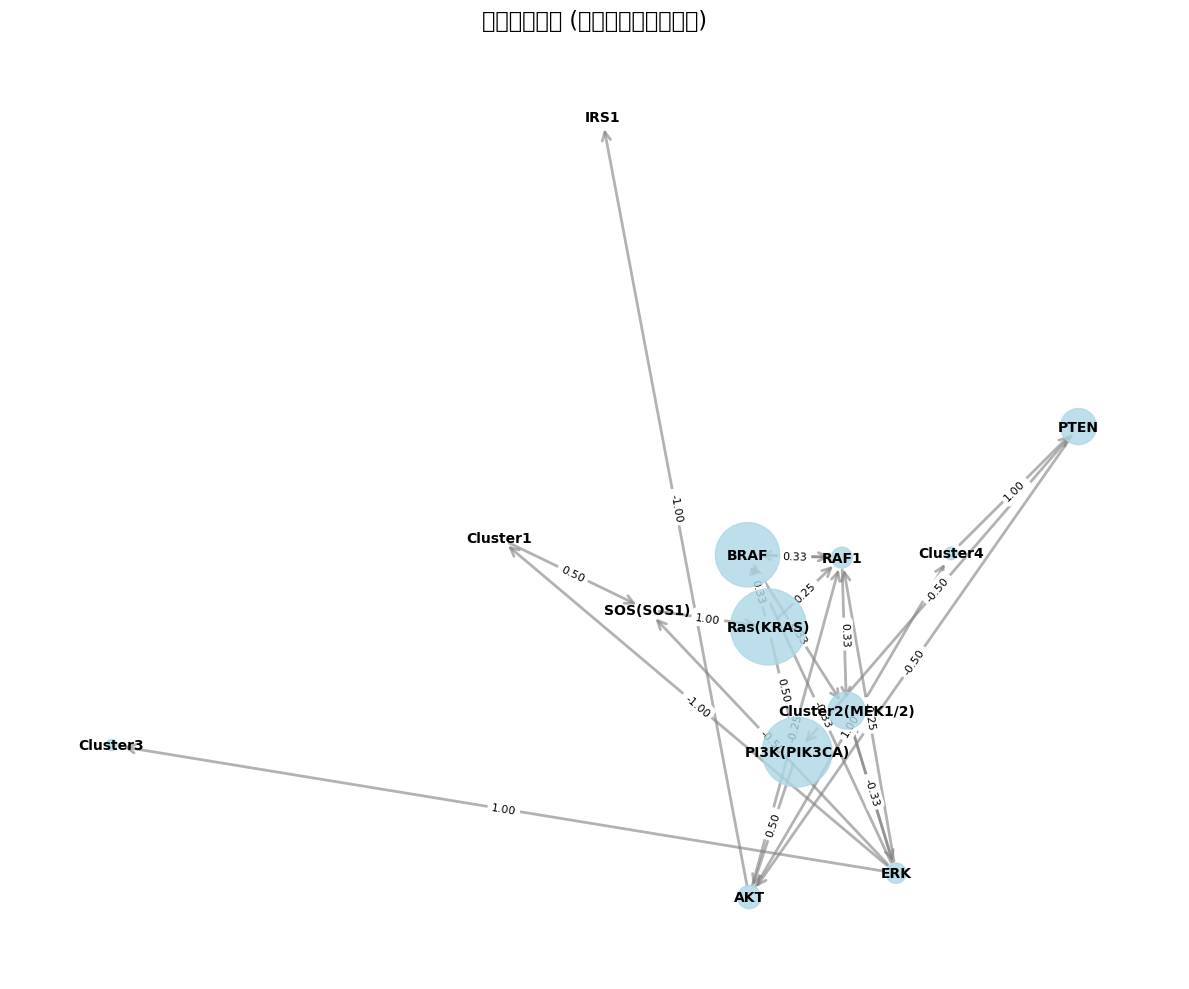


网络可视化已保存为 network_visualization.png


In [15]:
# 9.4 网络可视化（可选）
try:
    import matplotlib.pyplot as plt
    
    # 创建网络可视化
    plt.figure(figsize=(12, 10))
    
    # 使用节点重要性作为节点大小
    node_sizes = [3000 * (importance / node_importance.max()) for importance in node_importance.values]
    
    # 设置布局
    pos = nx.spring_layout(G, seed=42)
    
    # 绘制节点
    nx.draw_networkx_nodes(G, pos, 
                          node_size=node_sizes,
                          node_color='lightblue',
                          alpha=0.8)
    
    # 绘制边
    nx.draw_networkx_edges(G, pos, 
                          arrowstyle='->',
                          arrowsize=15,
                          edge_color='gray',
                          alpha=0.6,
                          width=2)
    
    # 添加节点标签
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    
    # 添加边权重标签
    edge_labels = {(u, v): f"{d['weight']:.2f}" 
                   for u, v, d in G.edges(data=True) if d['weight'] != 0}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    
    plt.title("信号通路网络 (节点大小表示重要性)", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('C:/毕业论文/数据/network_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\n网络可视化已保存为 network_visualization.png")
    
except ImportError:
    print("Matplotlib未安装，跳过可视化部分")

In [16]:
# 10. 额外的统计信息
print("\n额外的统计信息:")
print(f"总突变数: {len(df)}")
print(f"成功分析的突变数: {len(results_df) - results_df[nodes[0]].isna().sum()}")
print(f"网络节点数: {len(nodes)}")
print(f"网络边数: {G.number_of_edges()}")

# 计算每个节点的突变数量
node_mutation_counts = {}
for gene, node in gene_to_node.items():
    count = len(df[df['Gene'] == gene])
    node_mutation_counts[node] = node_mutation_counts.get(node, 0) + count

print("\n每个节点的突变数量:")
for node, count in node_mutation_counts.items():
    print(f"  {node}: {count} 个突变")

print("\n分析完成!")


额外的统计信息:
总突变数: 4267
成功分析的突变数: 4267
网络节点数: 13
网络边数: 23

每个节点的突变数量:
  Cluster1: 317 个突变
  SOS(SOS1): 452 个突变
  Ras(KRAS): 212 个突变
  BRAF: 518 个突变
  RAF1: 282 个突变
  Cluster2(MEK1/2): 406 个突变
  PI3K(PIK3CA): 1042 个突变
  PTEN: 1038 个突变
  AKT: 0 个突变
  ERK: 0 个突变

分析完成!
